In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from variable_print import p,ps,pst

#from tensorized_dp import TensorDP
from gridworld import GridworldEnv
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## `GridWorld` 생성

`nx x ny`의 칸을 가진 `GridworldEnv`

In [5]:
nx = 5
ny = 5
env = GridworldEnv([ny, nx])

## 동적계획법 '에이전트' 초기화하기
* 동적 게획법에서는 `에이전트`개념을 사용하지 않음   
```python
class TensorDP:
    def __init__(self,
                 gamma=1.0,
                 error_tol=1e-5):
        ...        
```

In [6]:
class TensorDP:
    @classmethod
    def add_method(cls, fun):
      setattr(cls, fun.__name__, fun)
      return fun

    def __init__(self, gamma=1.0, error_tol=1e-5):
        self.gamma = gamma
        self.error_tol = error_tol
        # Following attributes will be set after call "set_env()"
        self.env = None  # environment
        self.policy = None  # policy
        self.ns = None  # Num. states
        self.na = None  # Num. actions
        self.P = None  # Transition tensor
        self.R = None  # Reward tensor

    def set_env(self, env, policy=None):
        self.env = env
        if policy is None: self.policy = np.ones([env.nS, env.nA]) / env.nA
        self.ns = env.nS
        self.na = env.nA
        self.P = env.P_tensor  # Rank 3 tensor (a,s,s'):(4,25,25)
        self.R = env.R_tensor  # Rank 2 tensor (s,a):(25,4)
        print(f"Environment : #state = {env.nS} , #actions = {env.nA} ")

    def reset_policy(self):
        self.policy = np.ones([self.ns, self.na]) / self.na

    def set_policy(self, policy):
        self.policy = policy

    def get_r_pi(self, policy): #r_pi(s,)<-sum(pilicy(s,a)*R(s,a)))
        r_pi = (policy * self.R).sum(axis=-1) #(s,)
        return r_pi

    def get_p_pi(self, policy): # (s,s')<-(s,a)*(a,s,s')
        p_pi = np.einsum("na,anm->nm", policy, self.P) #(s,s')
        return p_pi

**TensorDP agent 생성**

In [7]:
dp_agent = TensorDP()

### DP agent에 환경 정보 설정

```python
    def set_env(self, env, policy=None):
        self.env = env
        if policy is None:
            self.policy = np.ones([env.nS, env.nA]) / env.nA #(s,a)<- 1/a
        self.ns = env.nS  
        self.na = env.nA
        self.P = env.P_tensor  # Rank 3 tensor (a,s,s')  
        self.R = env.R_tensor  # Rank 2 tensor (s,a)
        print(f"Environment : #state = {env.nS} , #actions = {env.nA} ")

```

**TensorDP agent에 GridWorldEnv 설정**

In [8]:
dp_agent.set_env(env)

Environment : #state = 25 , #actions = 4 


## 정책 평가 (Policy evaluation)

정책 평가 : Bellman expectation backup operator $T$ 가 수렴할때까지 반복하여, 정책함수 $\pi$ 에 대한 가치함수인 $V^{\pi}$ 를 찾는 알고리즘  

$$T :  T^{\pi}(V) \leftarrow R^{\pi} + \gamma P^{\pi} V$$


### $R^{\pi}$ 계산 : 상태s에서 얻을 수 있는 보상의 기댓값     

$$R^{\pi}_s = \sum_{a \in \cal{A}} \pi(a|s) R_s^a $$

모든 상태$s$에 대한 $R$은 위의 수식으로 정의되는 열 벡터(s,)

**Numpy 수식 표현**


```python
# r_pi(s,) <- r_pi(s,a) <- policy(s,a)*R(s,a)
def get_r_pi(self, policy):
    r_pi = (policy * self.R).sum(axis=-1)  # *:element-wise    
    ps(self.R)
    return r_pi
```

In [9]:
policy = dp_agent.policy         # (s,a):(25,4)
R = dp_agent.env.R_tensor        # (s,a):(25,4)
r_pi = dp_agent.get_r_pi(policy) # (s,):(25,)

ps(policy,"policy")
ps(R,"R")
ps(r_pi,"r_pi")

<<policy>> Shape(25, 4)
<<R>> Shape(25, 4)
<<r_pi>> Shape(25,)


In [10]:
p(policy,"Policy")

<<Policy>>:
Shape:(25, 4)
Type: <class 'numpy.ndarray'>
Values: [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


In [11]:
p(R,"Reward")

<<Reward>>:
Shape:(25, 4)
Type: <class 'numpy.ndarray'>
Values: [[ 0.  0.  0.  0.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [-1. -1. -1. -1.]
 [ 0.  0.  0.  0.]]


In [12]:
print("r_pi\n",r_pi)

r_pi
 [ 0. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1.  0.]


### $P^{\pi}$ 함수 계산하기

$$P^{\pi}_{ss'} = \sum_{a \in \cal{A}} \pi(a|s) P_{ss'}^a $$

각 $P^{\pi}_{ss'}$는 상태천이 행렬  
$s$번째 열(row) $s'$번째 행(column)의 원소입니다. 따라서 $P^{\pi} \in \mathbb{R}^{|\cal{S}|\times|\cal{S}|}$는 행렬  


```python
# p_pi(s,s') <- policy(s,a)P(a,s,s')  
def get_p_pi(self, policy):
    # np.einsum(Einstein summation convention)  
    p_pi = np.einsum("na,anm->nm", policy, self.P)
    return p_pi #(s,s')
```

In [13]:
policy = dp_agent.policy         # (s,a):(25,4)
P = dp_agent.P                   # = dp_agent.env.P_tensor
#P = dp_agent.env.P_tensor       # (a,s,s'):(4,25,25)
p_pi = dp_agent.get_p_pi(policy) # (s,s'):(25,25)

ps(policy,"policy")
ps(P,"P")
ps(p_pi,"p_pi")

<<policy>> Shape(25, 4)
<<P>> Shape(4, 25, 25)
<<p_pi>> Shape(25, 25)


**random 정책에서의 $P^\pi$ 확인:p=0.25**

In [14]:
pd.DataFrame(p_pi)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.25,0.25,0.25,0.00,0.00,0.00,0.25,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.25,0.25,0.25,0.00,0.00,0.00,0.25,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.25,0.25,0.25,0.00,0.00,0.00,0.25,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.25,0.50,0.00,0.00,0.00,0.00,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,0.25,0.00,0.00,0.00,0.00,0.25,0.25,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,0.00,0.25,0.00,0.00,0.00,0.25,0.00,0.25,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.25,0.00,0.00,0.00,0.25,0.00,0.25,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,0.00,0.00,0.25,0.00,0.00,0.00,0.25,0.00,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,0.00,0.00,0.00,0.00,0.25,0.00,0.00,0.00,0.25,0.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 정책평가 계산하기  
$V^\pi ← R^\pi + \gamma*P^\pi*V^\pi$

In [15]:
@TensorDP.add_method
def policy_evaluation(self, policy, v_init=None):
    r_pi = self.get_r_pi(policy)  #(s,)
    p_pi = self.get_p_pi(policy)  #(s,s')

    if v_init is None: v_old = np.zeros(self.ns)
    else:              v_old = v_init
    while True:
        # perform bellman expectation back
        # v(s,) <- r_pi(s,) + 1. * p_pi(s,s')*v(s,)
        v_new = r_pi + self.gamma * np.matmul(p_pi, v_old)

        # check convergence
        bellman_error = np.linalg.norm(v_new - v_old)#vector or matrix norm
        if bellman_error <= self.error_tol: break
        else: v_old = v_new
    return v_new

In [16]:
policy = dp_agent.policy         #(s,a):(25,4)
p_pi = dp_agent.get_p_pi(policy) #(s,s'):(25,25)
v_pi = dp_agent.policy_evaluation(policy) #(s,):(25,)

# np.matmul(p_pi, v_old):(s,)
ps(policy,"policy")
ps(p_pi,'p_pi')
ps(v_pi,"v_new")

<<policy>> Shape(25, 4)
<<p_pi>> Shape(25, 25)
<<v_new>> Shape(25,)


In [17]:
pd.DataFrame(v_pi)

,0
0,0.000000
1,-22.999954
2,-34.333263
3,-39.666584
4,-41.666580
5,-22.999954
6,-30.666605
7,-36.333259
8,-38.999920
9,-39.666584


### 랜덤 정책함수로 초기화 된 `dp_agent`policy 확인

In [18]:
p(dp_agent.policy) # (25,4):[[0.25 0.25 0.25 0.25][]...[]]

<<>>:
Shape:(25, 4)
Type: <class 'numpy.ndarray'>
Values: [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


### 랜덤 정책함수 평가하기

현재의 정책에 대한 v_pi 계산 : `policy_evaluation()`

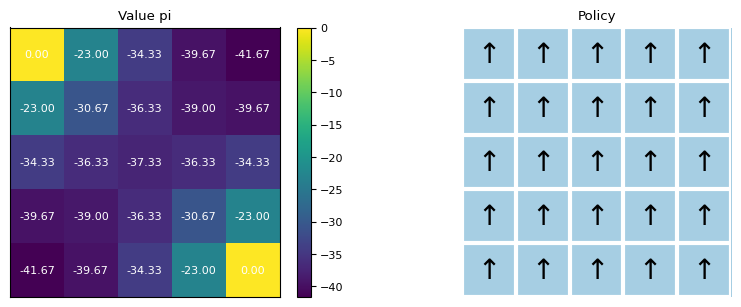

In [19]:
fig, ax = plt.subplots(1,2, figsize=(10,3.5))

v_pi = dp_agent.policy_evaluation(policy)

visualize_value_function(ax[0], v_pi, nx, ny)
_ = ax[0].set_title("Value pi")

visualize_policy(ax[1], dp_agent.policy, nx, ny)
_ = ax[1].set_title("Policy")

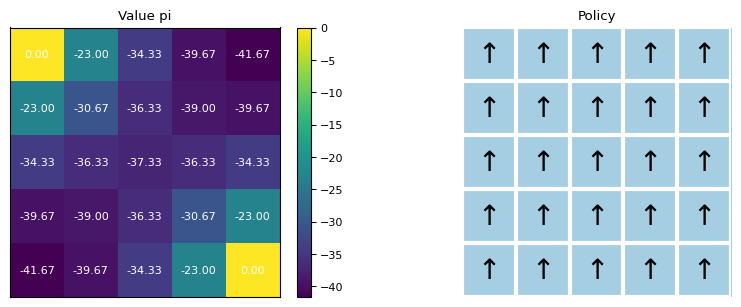

## 정책 개선 policy_improvement  

greedy policy improvement 수행

> Greedy 정책개선  
> 1. $Q^\pi(s,a) = R_s^{a} + \gamma \Sigma_{s' \in \cal{S}}P_{ss'}^aV^{\pi}(s')$ 계산    

> 2. $\pi'(a|s) \leftarrow$  $max_a Q^{\pi}(s,a)$인 $a$ 에 대해서 1로, 나머지는 0  



> `policy_improved = np.zeros_like(policy)`: 0으로 초기화  

> `policy_improved[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1` <br>
: 각 $s$에 대해 가장 큰 $Q(s,a)$를 $a$의 ploicy를 1로 설정    



In [20]:
@TensorDP.add_method
def policy_improvement(self, policy, v_pi=None):
    if policy is None: policy = self.policy
    if v_pi is None: v_pi = self.policy_evaluation(policy)

    # (1) Compute Q_pi(s,a) from V_pi(s,)
    r_pi = self.get_r_pi(policy)   #(s,)
    #q_pi(a,s)<-r_pi(s,) + P:(a,s,s') o v_pi:(s,)
    q_pi = r_pi + self.gamma * self.P.dot(v_pi)
    # (2) Greedy improvement
    policy_improved = np.zeros_like(policy) #(s,a)<- 0
    policy_improved[np.arange(q_pi.shape[1]), q_pi.argmax(axis=0)] = 1
    return policy_improved #(s,a)

In [21]:
dp_agent.reset_policy()

In [22]:
#dp_agent.reset_policy()
policy = dp_agent.policy # (s,a):(25,4)
print("old_policy[:7]\n",policy[:7])
new_policy = dp_agent.policy_improvement(policy)
print("new_policy[:7]\n",new_policy[:7])

old_policy[:7]
 [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
new_policy[:7]
 [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


### 정책 update

* 명시적 policy update

In [23]:
policy = dp_agent.policy
print("old_policy\n",policy[:7])
dp_agent.set_policy(new_policy)
policy = dp_agent.policy
print("new_policy\n",policy[:7])

old_policy
 [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
new_policy
 [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


**개선된 정책하에서 계산된 생태가치 및 개선된 정책 시각화**

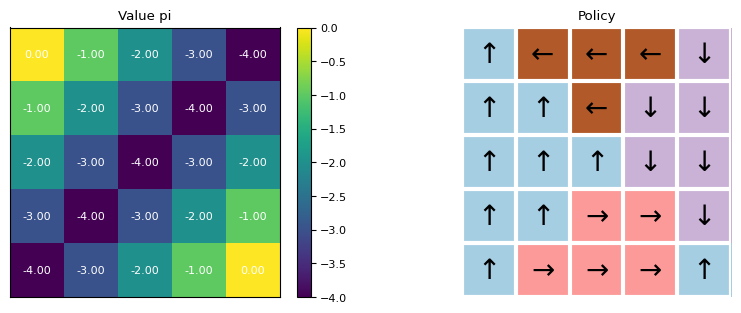

In [24]:
v_pi = dp_agent.policy_evaluation(policy)
fig, ax = plt.subplots(1,2, figsize=(10,3.5))
visualize_value_function(ax[0], v_pi, nx, ny)
_ = ax[0].set_title("Value pi")
visualize_policy(ax[1], dp_agent.policy, nx, ny)
_ = ax[1].set_title("Policy")

v_new = v_pi # 개선된 정책으로 찾은 v(s), pi(s,a)

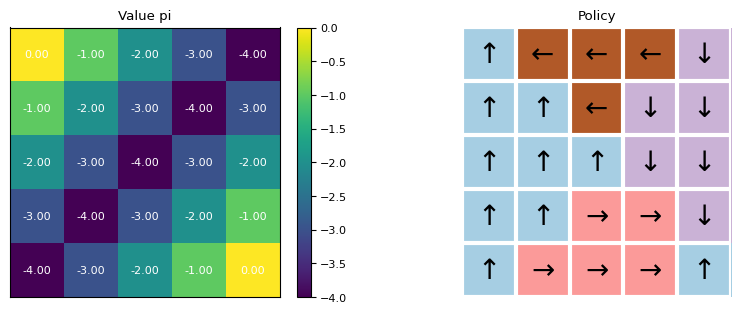

## 정책반복 policy_iteration

In [ ]:
@TensorDP.add_method
def policy_iteration(self, policy=None):
    if policy is None: pi_old = self.policy
    else:              pi_old = policy

    info = dict()
    info['v'] = list()
    info['pi'] = list()
    info['converge'] = None

    steps = 0
    converged = False
    while True:
        v_old = self.policy_evaluation(pi_old)
        pi_improved = self.policy_improvement(pi_old, v_old)
        steps += 1

        info['v'].append(v_old)
        info['pi'].append(pi_old)

        # check convergence
        policy_gap = np.linalg.norm(pi_improved - pi_old)
        print(f"iter[{steps:02d}] policy gap : {policy_gap:.7f}")
        if policy_gap <= self.error_tol:
            if not converged:  # record the first moment step
                info['converge'] = steps
            break
        else:
            pi_old = pi_improved
    return info

In [ ]:
dp_agent.reset_policy()
info_pi = dp_agent.policy_iteration()

iter[01] policy gap : 4.3301270
iter[02] policy gap : 2.4494897
iter[03] policy gap : 0.0000000


In [ ]:
print(info_pi.keys())      # dict_keys(['v', 'pi', 'converge'])
p(info_pi["v"],"V")        # V[]:(steps,s)(3,25)
p(info_pi["pi"],"PI")      # PI[]:(steps,s,a)(3,25,4)
p(info_pi["converge"],"Converge") # steps=3

In [ ]:
figsize_mul = 5
steps = info_pi['converge']

fig, ax = plt.subplots(nrows=steps, ncols=2, figsize=(steps * figsize_mul,
                                         figsize_mul * 2))

for i in range(steps):
    visualize_value_function(ax[i][0],info_pi['v'][i], nx, ny)
    visualize_policy(ax[i][1], info_pi['pi'][i], nx, ny)

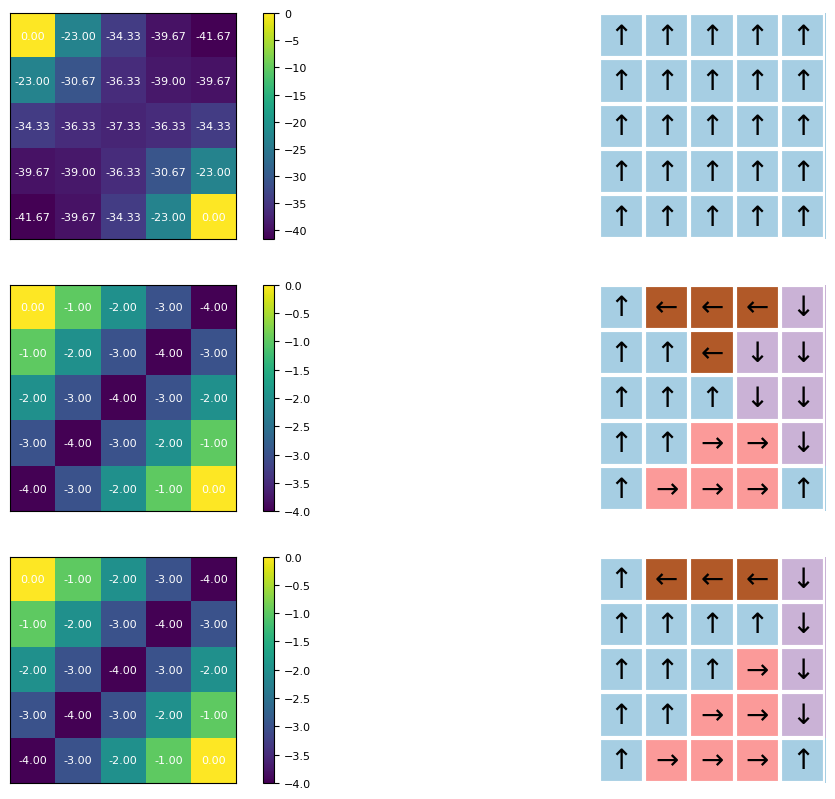